In [2]:
import pandas as pd
import seaborn as sns

print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)

Pandas: 3.0.6
Seaborn: 0.13.2


Loading dataset and Display missing values:

In [3]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset ONCE
df = sns.load_dataset("titanic")

# Save the original dataset immediately
df.to_csv("titanic.csv", index=False)

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Dataset shape
print("Dataset shape:", df.shape)

# Dataset information
print("\nDataset information:")
df.info()

# Statistical summary
print("\nStatistical summary:")
df.describe()

Dataset shape: (891, 15)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Statistical summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Missing values
missing_count = df.isnull().sum()

# Missing percentage
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


Handling Missing Values:

In [6]:

#Create copy of df without changing the df after cleaning
df_clean=df.copy()

#1.Drop the rows of embarked and embark_town
df_clean=df_clean.dropna(subset=['embarked','embark_town'])

#2.Drop the column of deck
df_clean=df_clean.drop(columns=['deck'])

#3.Impute the age with median
age_median=df_clean['age'].median()
df_clean['age']=df_clean['age'].fillna(age_median)

#Display new shape
print("Original shape:",df.shape)
print("Cleaned shape:",df_clean.shape)


Original shape: (891, 15)
Cleaned shape: (889, 14)


In [7]:
# Check remaining missing values
remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Series([], dtype: int64)


In [8]:
#Save the cleaned data for the modeling notebook
df_clean.to_csv("titanic_clean.csv",index=False)

print("Cleaned dataset saved successfully.")
print("Shape:",df_clean.shape)

Cleaned dataset saved successfully.
Shape: (889, 14)


Missing-Value Handling Justification:
The project specifies that columns with less than 5% missing values should be handled by dropping the affected rows, while columns with 5%–30% missing values should be imputed. Columns with very high missingness should either be dropped or have missingness explicitly encoded, with justification.

Based on the calculated missing percentages, embarked and embark_town have very low missingness and the affected rows were dropped. age has a moderate level of missingness and was therefore imputed using the median. deck has very high missingness, so it was dropped because imputing such a large proportion would be unreliable.

Univariate Analysis:

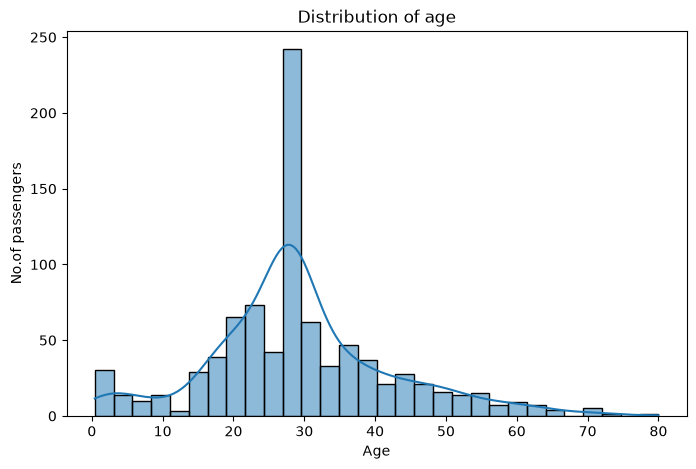

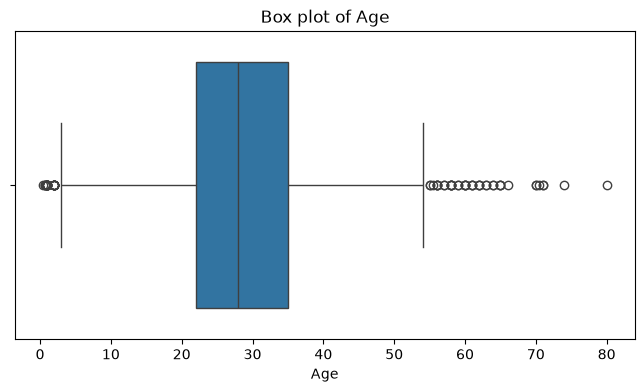

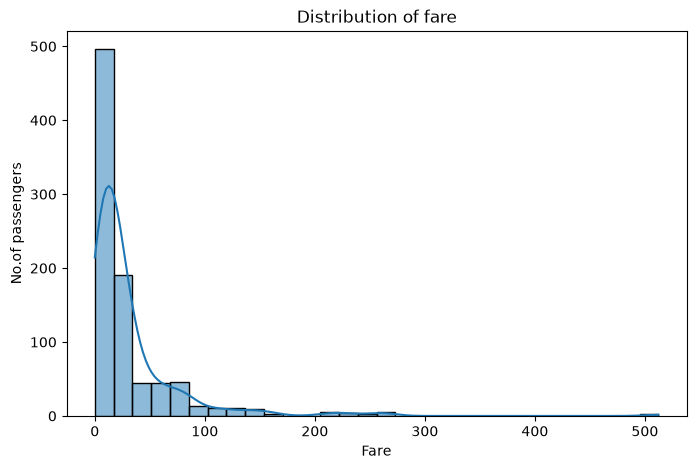

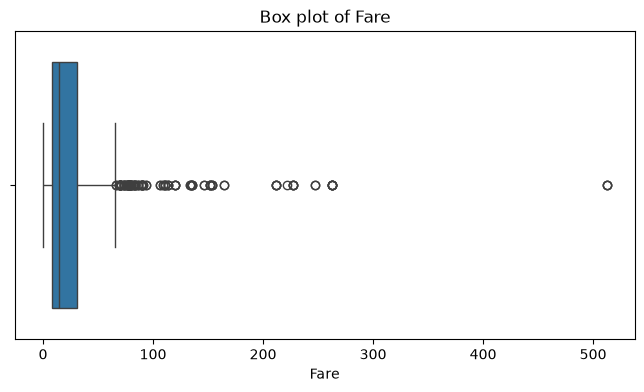

In [9]:
#Histogram and Boxplot for Age and Fare
import matplotlib.pyplot as plt
import seaborn as sns

#Age Histogram
plt.figure(figsize=(8,5))
sns.histplot(df_clean['age'],bins=30,kde=True)
plt.title("Distribution of age")
plt.xlabel("Age")
plt.ylabel("No.of passengers")
plt.show()

#Age boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['age'])
plt.title("Box plot of Age")
plt.xlabel("Age")
plt.show()

#Fare Histogram
plt.figure(figsize=(8,5))
sns.histplot(df_clean['fare'],bins=30,kde=True)
plt.title("Distribution of fare")
plt.xlabel("Fare")
plt.ylabel("No.of passengers")
plt.show()

#Fare boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['fare'])
plt.title("Box plot of Fare")
plt.xlabel("Fare")
plt.show()



In [10]:
#Calculate IQR outliers analysis
def calculate_iqr_outliers(series):
    Q1=series.quantile(0.25)
    Q3=series.quantile(0.75)

    IQR=Q3-Q1

    lower_bound=Q1-(1.5*IQR)
    upper_bound=Q3+(1.5*IQR)

    outliers = series[
        (series<lower_bound) | 
        (series>upper_bound)
    ]
    return Q1,Q3,IQR,lower_bound,upper_bound,len(outliers)

#Age
age_q1, age_q3, age_iqr, age_lower, age_upper, age_outliers= calculate_iqr_outliers(df_clean["age"])

#Fare
fare_q1,fare_q3,fare_iqr,fare_lower,fare_upper,fare_outliers= calculate_iqr_outliers(df_clean["fare"])


print("\nAGE")
print("Q1:",age_q1)
print("Q3:",age_q3)
print("IQR:",age_iqr)
print("Lower bound:",age_lower)
print("Upper bound:",age_upper)
print("No.of outliers:",age_outliers)

print("\nFARE")
print("Q1:",fare_q1)
print("Q3:",fare_q3)
print("IQR:",fare_iqr)
print("Lower bound:",fare_lower)
print("Upper bound:",fare_upper)
print("No.of outliers:",fare_outliers)


AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
No.of outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
No.of outliers: 114


In [11]:
#mean,median and mode
#Age Statistics
print("AGE")
print("Mean:",df_clean['age'].mean())
print("Median:",df_clean['age'].median())
print("Mode:",df_clean['age'].mode().tolist())

#Fare Statistics
print("FARE")
print("Mean:",df_clean['fare'].mean())
print("Median:",df_clean['fare'].median())
print("Mode:",df_clean['fare'].mode().tolist())

#Skewness
print("\n SKEWNESS")
print("Age skewness:",df_clean['age'].skew())
print("Fare skewness:",df_clean['fare'].skew())

AGE
Mean: 29.315151856017994
Median: 28.0
Mode: [28.0]
FARE
Mean: 32.09668087739032
Median: 14.4542
Mode: [8.05]

 SKEWNESS
Age skewness: 0.5080100783148638
Fare skewness: 4.801440211044194


### Univariate Analysis Interpretation

**Age:** The age distribution is moderately right-skewed, with a mean of 29.32 being higher than the median of 28.00 and a positive skewness of 0.51. The IQR method identifies 65 age observations as outliers.

**Fare:** The fare distribution is strongly right-skewed, with the mean of 32.10 substantially higher than the median of 14.45 and a positive skewness of 4.80. The box plot and IQR method identify 114 fare observations as outliers, indicating the presence of some passengers with substantially higher fares.

Bivariate Analysis

In [12]:
#survival rate by sex
male_survival=df_clean.loc[df_clean['sex']=="male","survived"].mean()
female_survival=df_clean.loc[df_clean['sex']=="female",'survived'].mean()

print("Male survival rate:",male_survival)
print("Female survival rate:",female_survival)

print("="*50)

#survival rate by pclass
first_class=df_clean.loc[df_clean["pclass"]==1,"survived"].mean()
second_class=df_clean.loc[df_clean["pclass"]==2,"survived"].mean()
third_class=df_clean.loc[df_clean["pclass"]==3,"survived"].mean()

print("1st class survival rate:",first_class)
print("2nd class survival rate:",second_class)
print("3rd class survival rate:",third_class)

print("="*50)

#Survival rate by sex+pclass
for sex in ["male","female"]:
    for pclass in [1,2,3]:
        mask=(
            (df_clean['sex']==sex) &
            (df_clean['pclass']==pclass)
        )
        survival_rate=df_clean.loc[mask,"survived"].mean()
        print("sex:",sex,"-class:",pclass,"-survival_rate:",survival_rate)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154
1st class survival rate: 0.6261682242990654
2nd class survival rate: 0.47282608695652173
3rd class survival rate: 0.24236252545824846
sex: male -class: 1 -survival_rate: 0.36885245901639346
sex: male -class: 2 -survival_rate: 0.1574074074074074
sex: male -class: 3 -survival_rate: 0.13544668587896252
sex: female -class: 1 -survival_rate: 0.967391304347826
sex: female -class: 2 -survival_rate: 0.9210526315789473
sex: female -class: 3 -survival_rate: 0.5


| Group     |       Survival rate |
| --------- | ------------------: |
| Male      | 0.1889 → **18.89%** |
| Female    | 0.7404 → **74.04%** |
| 1st class | 0.6262 → **62.62%** |
| 2nd class | 0.4728 → **47.28%** |
| 3rd class | 0.2424 → **24.24%** |

For the combined groups:

Male, 1st class → 36.89%
Male, 2nd class → 15.74%
Male, 3rd class → 13.54%
Female, 1st class → 96.74%
Female, 2nd class → 92.11%
Female, 3rd class → 50.00%

These results show that survival rates differ substantially by sex and passenger class.

In [13]:
#Correlation analysis for 6 columns
correlation_columns=['survived','pclass','age','sibsp','parch','fare']
correlation_matrix=df_clean[correlation_columns].corr()
print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


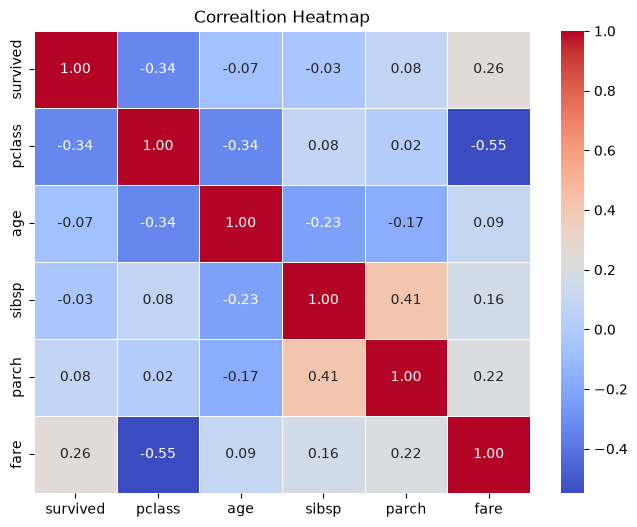

In [14]:
#Heatmap for corrleation matrix
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt='.2f',linewidths=0.5)
plt.title("Correaltion Heatmap")
plt.show()

In [15]:
#Find the strongest correlations
corr_abs=correlation_matrix.abs()

#remove the diagonal
import numpy as np

corr_abs = corr_abs.mask(
    np.eye(corr_abs.shape[0], dtype=bool)
)

#get the two strongest correlations
strongest_pairs=(
            corr_abs.unstack().sort_values(ascending=False)
)

#remove duplicate pairs
seen=set()
top_pairs=[]

for (col1,col2),values in strongest_pairs.items():
    pairs=tuple(sorted([col1,col2]))
    
    if pairs not in seen:
        seen.add(pairs)
        top_pairs.append((col1,col2,correlation_matrix.loc[col1,col2]))

    if len(top_pairs) == 2:
        break
print("Two strongest absolute off diagonal correlations:")
for col1,col2,values in top_pairs:
    print(f"{col1} vs {col2}:{values:.4f}")

Two strongest absolute off diagonal correlations:
pclass vs fare:-0.5482
sibsp vs parch:0.4145


Correlation interpretations:
pclass and fare have a negative correlation (correlation = -0.5482). This means that changes in one variable are associated with negative changes in the other variable.
sibsp and parch have a positive correlation (correlation = 0.4145). This means that changes in one variable are associated with positive changes in the other variable.

Multivariate Analysis

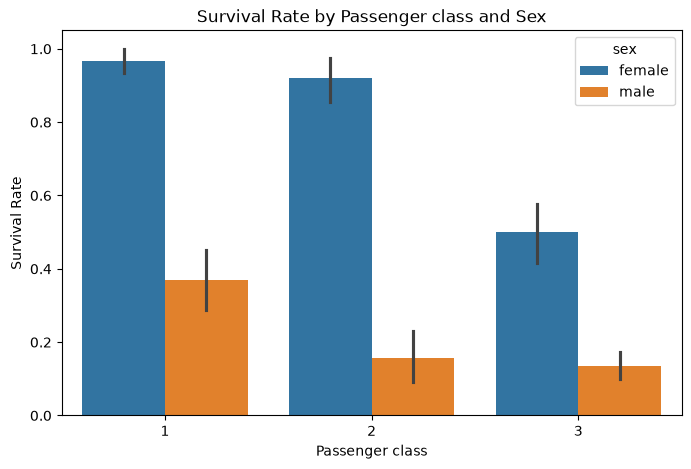

In [16]:
#Chart-1:Survival rate by sex and passengers class
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean,x="pclass",y="survived",hue="sex")
plt.title("Survival Rate by Passenger class and Sex")
plt.xlabel("Passenger class")
plt.ylabel("Survival Rate")
plt.show()

### Interpretation

Survival rates differed substantially by both passenger class and sex. Female passengers had higher survival rates than male passengers in all three passenger classes.

Among females, survival was highest in 1st class (about 97%) and decreased to about 92% in 2nd class and 50% in 3rd class. Among males, survival was lower across all classes, with the highest rate in 1st class (about 37%) and lower rates in 2nd and 3rd class.

Overall, the chart shows that both sex and passenger class were important factors associated with survival.

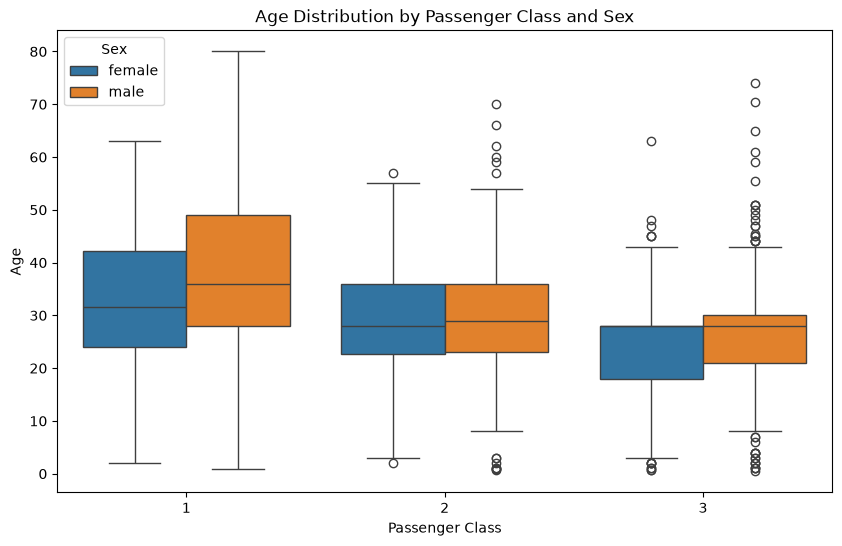

In [17]:
#Chart-2:Age Distribution by pclass and sex
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="age",
    hue="sex"
)

plt.title("Age Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.legend(title="Sex")
plt.show()

### Interpretation

Age distributions differ across passenger classes and between males and females. First-class passengers generally have higher median ages than third-class passengers, while the median ages in second class are lower than first class.

The chart also shows several older and younger age outliers, particularly in the second and third classes. Overall, passenger class and sex are associated with differences in the age distribution of the passengers.

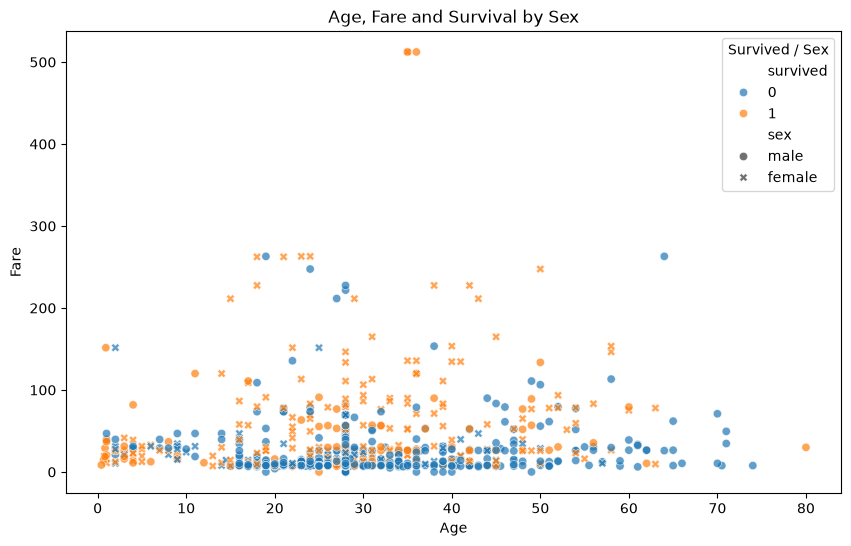

In [18]:
#Chart-3:Relation between age,fare by survival status with sex
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age, Fare and Survival by Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived / Sex")
plt.show()

### Interpretation

The chart shows the relationship between age, fare, survival status, and sex. Most passengers paid relatively low fares, while a small number of passengers paid very high fares.

Surviving passengers are more visible across the higher-fare range, while many non-surviving passengers are concentrated at lower fares. The chart also shows that both male and female passengers appear across different age and fare ranges, indicating that survival was associated with multiple passenger characteristics rather than age alone.

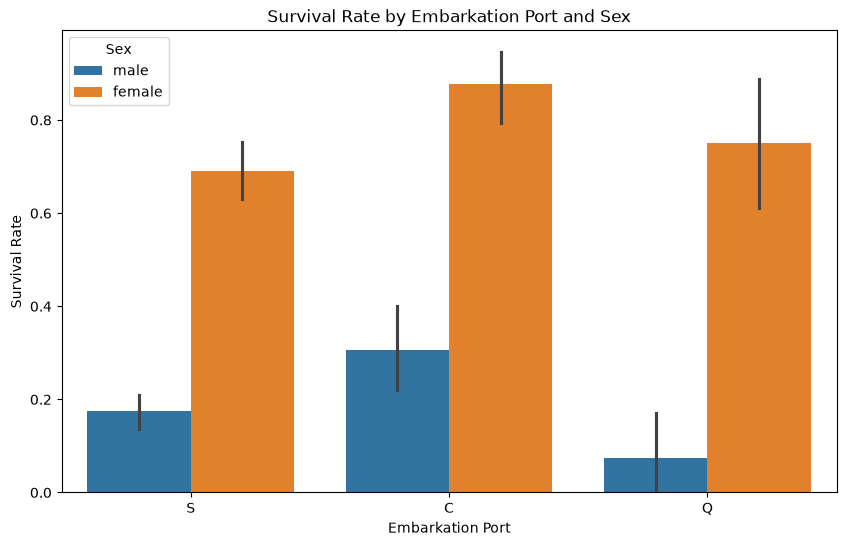

In [19]:
#Chart-4:Survival Rate by embarked port and sex
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="embarked",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Embarkation Port and Sex")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")
plt.legend(title="Sex")
plt.show()

### Interpretation

Survival rates differ across embarkation ports and between male and female passengers. Female passengers have substantially higher survival rates than male passengers at all three ports.

Female survival is highest among passengers embarking at port C, while male survival is highest at port C compared with ports S and Q. Overall, the chart shows that sex is strongly associated with survival, while survival rates also vary across embarkation ports.

Z-score for age and fare

In [20]:
from sklearn.preprocessing import StandardScaler

# Columns required for z-score standardization
cols = ['age', 'fare']

# ---------------- BEFORE STANDARDIZATION ----------------
print("BEFORE STANDARDIZATION")
print(df_clean[cols].agg(['mean', 'std']).round(4))

# ---------------- Z-SCORE STANDARDIZATION ----------------
scaler = StandardScaler()

z_values = scaler.fit_transform(df_clean[cols])

df_zscore = df_clean.copy()

df_zscore[['age_z', 'fare_z']] = z_values

# ---------------- AFTER STANDARDIZATION ----------------
print("\nAFTER STANDARDIZATION")
print(df_zscore[['age_z', 'fare_z']].agg(['mean', 'std']).round(4))

BEFORE STANDARDIZATION
          age     fare
mean  29.3152  32.0967
std   12.9849  49.6975

AFTER STANDARDIZATION
       age_z  fare_z
mean  0.0000  0.0000
std   1.0006  1.0006


### Z-Score Standardization Interpretation

Before standardization, age and fare have different means and standard deviations.

After applying z-score standardization, the transformed age and fare columns have approximately mean 0 and standard deviation 1. This confirms that the standardization worked correctly.

This transformation is used only as an exploratory EDA sanity check. The standardized columns are not used as inputs to the modeling pipeline. The modeling pipeline will perform its own train-only scaling to avoid data leakage.